# Notebook 02 - Entrenamiento del Modelo Principal

Este notebook es el **camino critico** del proyecto. Orquesta las tres fases de entrenamiento y produce todos los artefactos que consume `TALLER_B4_T1.ipynb`.

**Regla de diseno:** este notebook no define funciones. Todo el codigo reutilizable vive en `src/`. Aqui solo importamos, ejecutamos y visualizamos.

---

## Flujo completo

```
datos crudos
    |
    v
[Seccion 1] Carga y preprocesado   ->  X_custom, X_dense, y_ext, s
    |
    v
[Seccion 2] Calibracion de k_ratio ->  k_ratio (percentil 95 del ratio train)
    |
    v
[Seccion 3] Fase 1: arquitectura   ->  best_model.keras + best_hparams
    |
    v
[Seccion 4] Fase 2: fairness       ->  pareto_data.csv + eleccion de lambda*
    |
    v
[Seccion 5] Entrenamientos finales ->  base_model.keras + fair_model.keras
    |
    v
[Seccion 6] Evaluacion en test     ->  results_table.csv
    |
    v
[Seccion 7] Persistencia           ->  preprocessing.joblib + processed_data.npz
```

---

**Artefactos que produce este notebook:**

| Artefacto | Entregable |
|---|---|
| `artifacts/best_model.keras` | Arquitectura ganadora del Tuner |
| `artifacts/base_model.keras` | Modelo base (lambda=0) |
| `artifacts/fair_model.keras` | Modelo justo (lambda=lambda*) |
| `artifacts/pareto_data.csv` | Curva de Pareto |
| `artifacts/results_table.csv` | Tabla comparativa base vs FAIR |
| Curvas de loss | Convergencia de ambos modelos |
| `artifacts/preprocessing.joblib` | Scalers para inferencia |
| `artifacts/processed_data.npz` | Arrays procesados (cache) |

## 0. Imports y configuracion

In [2]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
import keras_tuner as kt
from sklearn.metrics import roc_auc_score

sys.path.insert(0, os.path.abspath(".."))

from src.data import load_and_split, make_extended_y, save_preprocessing, save_processed
from src.model import FairCreditHyperModel
from src.losses import fairness_metrics

SEED      = 42
DATA_PATH = "../application_train.csv"
ARTIFACTS = "../artifacts"
os.makedirs(ARTIFACTS, exist_ok=True)

---

## 1. Carga y preprocesado de datos

`load_and_split` es el unico punto de entrada a los datos crudos. Aplica el routing en dos canales, el escalado heterogeneo y el split estratificado 70/15/15 sin fuga de informacion (todos los estadisticos se ajustan solo en train).

El resultado clave es `y_ext`, un array de shape `(N, 2)` que empaqueta:
- columna 0 -> `TARGET` (etiqueta real)
- columna 1 -> `CODE_GENDER` codificada como binaria (variable sensible `s`)

Esta estructura es el contrato de entrada de la FAIR loss: le permite calcular `BCE(y, y_hat)` y `rho(y_hat, s)^2` a partir de un unico tensor.

In [7]:
(X_custom_train, X_custom_val, X_custom_test,
 X_dense_train,  X_dense_val,  X_dense_test,
 y_train, y_val, y_test,
 s_train, s_val, s_test,
 scalers, feature_names) = load_and_split(DATA_PATH, seed=SEED)

y_train_ext = make_extended_y(y_train, s_train)
y_val_ext   = make_extended_y(y_val,   s_val)
y_test_ext  = make_extended_y(y_test,  s_test)

print("=== Shapes ===")
print(f"  X_custom : train {X_custom_train.shape}  val {X_custom_val.shape}  test {X_custom_test.shape}")
print(f"  X_dense  : train {X_dense_train.shape}  val {X_dense_val.shape}  test {X_dense_test.shape}")
print(f"  y_ext    : train {y_train_ext.shape}")
print(f"\nTasa de default (train): {y_train.mean():.4f}")
print(f"Proporcion M (s=1) train: {s_train.mean():.4f}")
print(f"\nFeatures custom : {feature_names['custom']}")
print(f"Features dense  : {feature_names['dense']}")

=== Shapes ===
  X_custom : train (215257, 2)  val (46127, 2)  test (46127, 2)
  X_dense  : train (215257, 8)  val (46127, 8)  test (46127, 8)
  y_ext    : train (215257, 2)

Tasa de default (train): 0.0807
Proporcion M (s=1) train: 0.3421

Features custom : ['AMT_CREDIT', 'AMT_INCOME_TOTAL']
Features dense  : ['AMT_ANNUITY', 'AGE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'is_imputed_EXT_SOURCE_1', 'is_imputed_EXT_SOURCE_2', 'is_imputed_EXT_SOURCE_3']


---

## 2. Calibracion de `k_ratio` para `DebtRatioCustomLayer`

La capa custom calcula `tanh(ratio / k_ratio)` donde `ratio = AMT_CREDIT / AMT_INCOME_TOTAL`.

`k_ratio` es una **constante no entrenable** que controla la escala de saturacion. Con `k_ratio = p95(ratio_train)`, el 95% de la distribucion de entrenamiento queda en la region de maxima resolucion de la `tanh`, y solo la cola mas extrema queda comprimida.

Cuando `ratio = k_ratio` -> `tanh(1) aprox 0.76`: no es saturacion completa, es compresion suave.

> **Anti-fuga:** `k_ratio` se calcula solo sobre `X_custom_train`. Usar el conjunto completo contaminaria el percentil con informacion de val y test.

> **Nota de implementacion:** se usa el nombre `k_ratio` (no `k`) para evitar colision con la variable de iteracion `for k in best_hparams_dict` en la seccion de hparams.

Percentil 95 del ratio (train) : 9.1453
tanh(1.0) = 0.7616  -> resolucion maxima en ratio = k_ratio
tanh(2.0) = 0.9640  -> compresion suave en ratio = 2*k_ratio


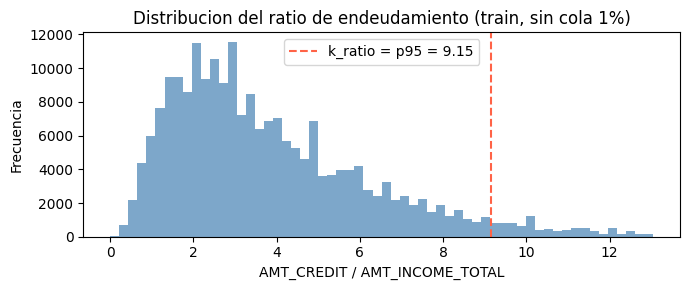

In [8]:
ratios = X_custom_train[:, 0] / (X_custom_train[:, 1] + 1e-6)
k_ratio = float(np.percentile(ratios, 95))

print(f"Percentil 95 del ratio (train) : {k_ratio:.4f}")
print(f"tanh(1.0) = {np.tanh(1.0):.4f}  -> resolucion maxima en ratio = k_ratio")
print(f"tanh(2.0) = {np.tanh(2.0):.4f}  -> compresion suave en ratio = 2*k_ratio")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(ratios[ratios < np.percentile(ratios, 99)],
        bins=60, color='steelblue', alpha=0.7)
ax.axvline(k_ratio, color='tomato', linestyle='--', label=f'k_ratio = p95 = {k_ratio:.2f}')
ax.set_xlabel('AMT_CREDIT / AMT_INCOME_TOTAL')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribucion del ratio de endeudamiento (train, sin cola 1%)')
ax.legend()
plt.tight_layout()
plt.show()

input_shape_custom = X_custom_train.shape[1]
input_shape_dense  = X_dense_train.shape[1]

---

## 3. Fase 1: Busqueda de arquitectura (lambda = 0)

El Tuner busca la **mejor arquitectura** del modelo de dos canales sin penalizacion de fairness (lambda = 0). El objetivo es maximizar `val_auc`.

### Por que AUC y no accuracy?

El dataset tiene un desbalance ~11:1. Un modelo que predice siempre 0 tiene accuracy aprox 91% pero AUC = 0.5. AUC mide la capacidad discriminativa independientemente del umbral y es robusta al desbalance.

### Espacio de busqueda (Fase 1)

| Hiperparametro | Rango |
|---|---|
| `num_layers` | 1, 2 |
| `units_i` | 16, 32, 48, 64 |
| `dropout_i` | 0.1, 0.2, 0.3, 0.4 |
| `lr` | 1e-3, 5e-4 |
| `lambda_fair` | fijo a 0.0 |

> **`fixed_hparams=None`** activa el modo de busqueda libre en `FairCreditHyperModel`.

In [11]:
hypermodel_arch = FairCreditHyperModel(
    input_shape_custom=input_shape_custom,
    input_shape_dense=input_shape_dense,
    k_ratio=k_ratio,
    fixed_hparams=None,
)

tuner_arch = kt.RandomSearch(
    hypermodel_arch,
    objective=kt.Objective("val_auc", direction="max"),
    max_trials=5,
    seed=SEED,
    directory=os.path.join(ARTIFACTS, "tuner_results"),
    project_name="fase1_arquitectura",
    overwrite=False,
)

early_stop_arch = keras.callbacks.EarlyStopping(
    monitor="val_auc", patience=5, restore_best_weights=True, mode="max"
)

tuner_arch.search_space_summary()

Reloading Tuner from ../artifacts\tuner_results\fase1_arquitectura\tuner0.json
Search space summary
Default search space size: 6
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 2, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 64, 'step': 16, 'sampling': 'linear'}
dropout_0 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.4, 'step': 0.1, 'sampling': 'linear'}
lr (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0005], 'ordered': True}
units_1 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 64, 'step': 16, 'sampling': 'linear'}
dropout_1 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.4, 'step': 0.1, 'sampling': 'linear'}


In [12]:
tuner_arch.search(
    [X_custom_train, X_dense_train], y_train_ext,
    validation_data=([X_custom_val, X_dense_val], y_val_ext),
    epochs=30,
    callbacks=[early_stop_arch],
    verbose=1,
)

Trial 6 Complete [00h 01m 05s]
val_auc: 0.7196489572525024

Best val_auc So Far: 0.7207615971565247
Total elapsed time: 01h 45m 31s


### Resultados de la Fase 1

Extraemos los mejores hiperparametros de arquitectura. Este diccionario (`best_hparams_dict`) se **congela** para la Fase 2: el Tuner no vuelve a explorar la arquitectura, solo varia lambda.

In [13]:
best_hp    = tuner_arch.get_best_hyperparameters(1)[0]
num_layers = best_hp.get("num_layers")

best_hparams_dict = {"num_layers": num_layers, "lr": best_hp.get("lr")}
for i in range(num_layers):
    best_hparams_dict[f"units_{i}"]   = best_hp.get(f"units_{i}")
    best_hparams_dict[f"dropout_{i}"] = best_hp.get(f"dropout_{i}")

print("Mejores hiperparametros de arquitectura:")
for hp_key, hp_val in best_hparams_dict.items():
    print(f"  {hp_key}: {hp_val}")

best_model = tuner_arch.get_best_models(1)[0]
best_model.save(os.path.join(ARTIFACTS, "best_model.keras"))
print("\nGuardado: artifacts/best_model.keras")

Mejores hiperparametros de arquitectura:
  num_layers: 2
  lr: 0.001
  units_0: 16
  dropout_0: 0.2
  units_1: 16
  dropout_1: 0.1

Guardado: artifacts/best_model.keras


C:\Users\bogar\AppData\Roaming\Python\Python313\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


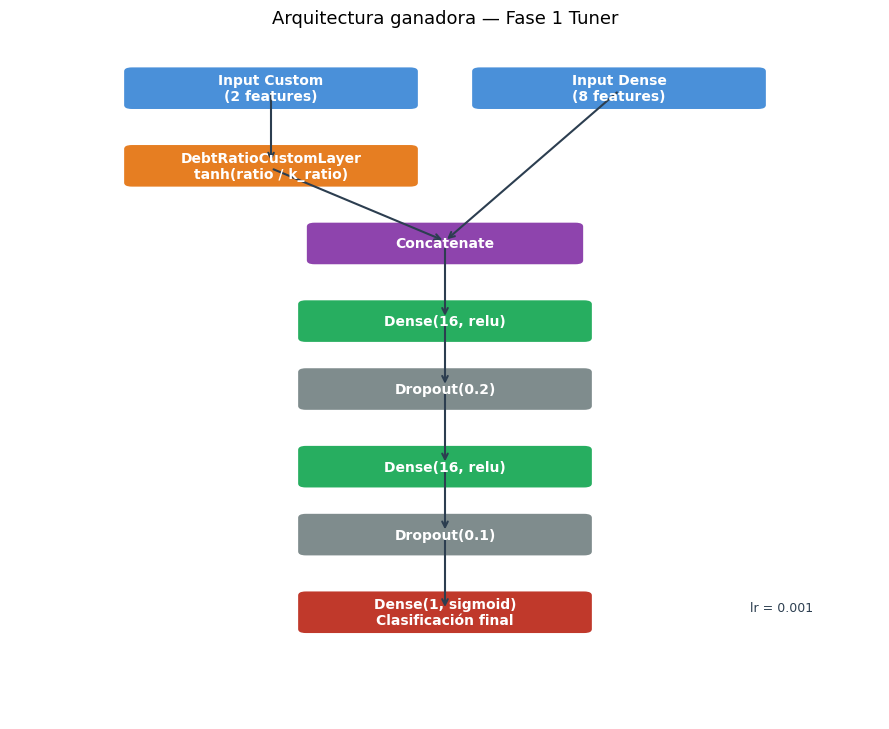

In [14]:
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

def draw_flowchart(best_hp, input_shape_custom, input_shape_dense):
    num_layers = best_hp.get("num_layers")
    lr         = best_hp.get("lr")
    layers_info = [
        (best_hp.get(f"units_{i}"), best_hp.get(f"dropout_{i}"))
        for i in range(num_layers)
    ]

    # Colores
    C_INPUT  = "#4A90D9"
    C_CUSTOM = "#E67E22"
    C_MERGE  = "#8E44AD"
    C_DENSE  = "#27AE60"
    C_DROP   = "#7F8C8D"
    C_OUT    = "#C0392B"

    fig, ax = plt.subplots(figsize=(9, 3 + num_layers * 2.2))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10 + num_layers * 2)
    ax.axis("off")

    def box(ax, x, y, text, color, width=3.2, height=0.7, fontsize=10):
        rect = mpatches.FancyBboxPatch(
            (x - width / 2, y - height / 2), width, height,
            boxstyle="round,pad=0.1", linewidth=1.5,
            edgecolor="white", facecolor=color, zorder=3,
        )
        ax.add_patch(rect)
        ax.text(x, y, text, ha="center", va="center",
                fontsize=fontsize, color="white", fontweight="bold", zorder=4)
        return y - height / 2  # bottom y

    def arrow(ax, x, y_from, y_to):
        ax.annotate("", xy=(x, y_to + 0.05), xytext=(x, y_from - 0.05),
                    arrowprops=dict(arrowstyle="->", color="#2C3E50", lw=1.5))

    def arrow2to1(ax, x_from, x_to, y_from, y_to):
        ax.annotate("", xy=(x_to, y_to + 0.05), xytext=(x_from, y_from - 0.05),
                    arrowprops=dict(arrowstyle="->", color="#2C3E50", lw=1.5,
                                   connectionstyle="arc3,rad=0.0"))

    top = 9 + num_layers * 2

    # Inputs
    box(ax, 3,   top, f"Input Custom\n({input_shape_custom} features)", C_INPUT)
    box(ax, 7,   top, f"Input Dense\n({input_shape_dense} features)",   C_INPUT)

    # DebtRatioLayer
    y_debt = top - 1.6
    box(ax, 3, y_debt, "DebtRatioCustomLayer\ntanh(ratio / k_ratio)", C_CUSTOM)
    arrow(ax, 3, top, y_debt)

    # Concat
    y_cat = y_debt - 1.6
    box(ax, 5, y_cat, "Concatenate", C_MERGE, width=3.0)
    arrow2to1(ax, 3, 5, y_debt, y_cat)
    arrow2to1(ax, 7, 5, top,    y_cat)

    y_cur = y_cat
    for i, (units, dropout) in enumerate(layers_info):
        y_d = y_cur - 1.6
        box(ax, 5, y_d, f"Dense({units}, relu)", C_DENSE)
        arrow(ax, 5, y_cur, y_d)

        y_drop = y_d - 1.4
        box(ax, 5, y_drop, f"Dropout({dropout})", C_DROP)
        arrow(ax, 5, y_d, y_drop)
        y_cur = y_drop

    y_out = y_cur - 1.6
    box(ax, 5, y_out, "Dense(1, sigmoid)\nClasificación final", C_OUT)
    arrow(ax, 5, y_cur, y_out)

    # Anotación lr
    ax.text(8.5, y_out + 0.1, f"lr = {lr}", fontsize=9,
            color="#2C3E50", va="center")

    plt.title("Arquitectura ganadora — Fase 1 Tuner", fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig(os.path.join(ARTIFACTS, "flowchart_modelo.png"), dpi=150, bbox_inches="tight")
    plt.show()

draw_flowchart(best_hp, input_shape_custom, input_shape_dense)


---

## 4. Fase 2: Busqueda de fairness y frontera de Pareto

Con la arquitectura fija, el Tuner explora **cinco valores de lambda** (`lambda_fair` en {0, 2, 10, 25, 50}). Cada trial produce un punto `(AUC, rho2_Pearson)`: a mayor lambda, mayor penalizacion de la correlacion con el genero -> menos sesgo pero potencialmente menor AUC.

### Por que correlacion de Pearson al cuadrado?

- El signo de `rho` no importa: queremos independencia estadistica (`rho -> 0`).
- Elevar al cuadrado garantiza que el gradiente empuja siempre hacia 0, sin importar la direccion.

### Frontera de Pareto

La curva resultante es el **trade-off AUC vs equidad**: no hay un unico lambda optimo universal. La eleccion de lambda* es una decision de negocio: cuanto AUC cedemos por equidad?

> **`fixed_hparams=best_hparams_dict`** activa el modo de arquitectura fija. El unico hiperparametro que varia es `lambda_fair`.

In [15]:
hypermodel_fair = FairCreditHyperModel(
    input_shape_custom=input_shape_custom,
    input_shape_dense=input_shape_dense,
    k_ratio=k_ratio,
    fixed_hparams=best_hparams_dict,
)

tuner_fair = kt.RandomSearch(
    hypermodel_fair,
    objective=kt.Objective("val_auc", direction="max"),
    max_trials=5,
    seed=SEED,
    directory=os.path.join(ARTIFACTS, "tuner_results"),
    project_name="fase2_fairness",
    overwrite=False,
)

early_stop_fair = keras.callbacks.EarlyStopping(
    monitor="val_auc", patience=8, restore_best_weights=True, mode="max"
)

tuner_fair.search(
    [X_custom_train, X_dense_train], y_train_ext,
    validation_data=([X_custom_val, X_dense_val], y_val_ext),
    epochs=50,
    callbacks=[early_stop_fair],
    verbose=1,
)

Reloading Tuner from ../artifacts\tuner_results\fase2_fairness\tuner0.json


### Construccion de `pareto_data.csv` y plot de Pareto

Extraemos `val_auc` y `val_fair_pearson_sq` de cada trial. Cada fila del CSV es un punto de la frontera: `(lambda_fair, val_auc, val_pearson_sq)`.

In [16]:
trials = tuner_fair.oracle.get_best_trials(num_trials=5)
pareto_rows = []
for trial in trials:
    pareto_rows.append({
        "lambda_fair":    trial.hyperparameters.get("lambda_fair"),
        "val_auc":        trial.metrics.get_best_value("val_auc"),
        "val_pearson_sq": trial.metrics.get_best_value("val_fair_pearson_sq"),
    })

pareto_df = pd.DataFrame(pareto_rows).sort_values("lambda_fair").reset_index(drop=True)
pareto_df.to_csv(os.path.join(ARTIFACTS, "pareto_data.csv"), index=False)
print(pareto_df.to_string(index=False))

 lambda_fair  val_auc  val_pearson_sq
         0.0 0.723529        0.035441
         2.0 0.707006        0.032963
        10.0 0.621417        0.031064
        25.0 0.574299        0.029023
        50.0 0.552166        0.028837


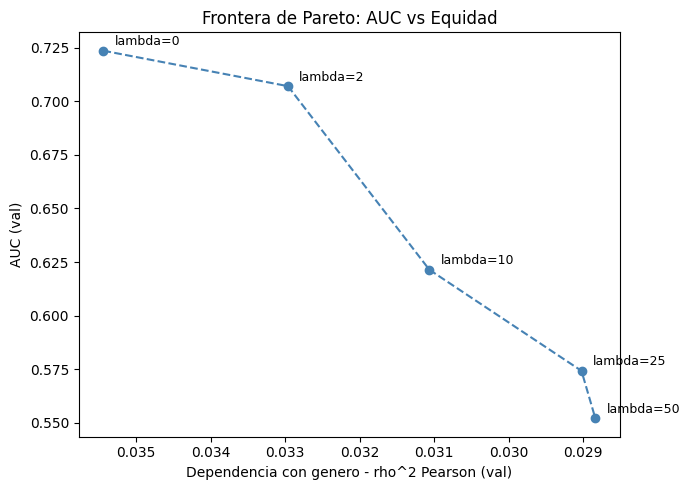

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(pareto_df["val_pearson_sq"], pareto_df["val_auc"],
        marker="o", linestyle="--", color="steelblue", linewidth=1.5)
for _, row in pareto_df.iterrows():
    ax.annotate(f"lambda={row['lambda_fair']:.0f}",
                (row["val_pearson_sq"], row["val_auc"]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)
ax.set_xlabel("Dependencia con genero - rho^2 Pearson (val)")
ax.set_ylabel("AUC (val)")
ax.set_title("Frontera de Pareto: AUC vs Equidad")
ax.invert_xaxis()
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS, "pareto_frontier.png"), dpi=150)
plt.show()

### Eleccion de lambda*

Seleccionamos el lambda que **minimiza la dependencia** (rho^2) entre todos los trials que mantienen un AUC de validacion por encima del umbral `AUC_MIN`. Este umbral es una decision de negocio.

Ajusta `AUC_MIN` segun los resultados de tu entorno.

In [18]:
AUC_MIN = 0.72  # ajustar segun resultados reales

candidatos = pareto_df[pareto_df["val_auc"] >= AUC_MIN]
if candidatos.empty:
    print(f"Ningun trial supera AUC={AUC_MIN}. Usando el mejor disponible.")
    candidatos = pareto_df

best_row    = candidatos.loc[candidatos["val_pearson_sq"].idxmin()]
lambda_star = float(best_row["lambda_fair"])

print(f"lambda* elegido      : {lambda_star}")
print(f"AUC (val)            : {best_row['val_auc']:.4f}")
print(f"rho2 Pearson (val)   : {best_row['val_pearson_sq']:.6f}")

lambda* elegido      : 0.0
AUC (val)            : 0.7235
rho2 Pearson (val)   : 0.035441


---

## 5. Entrenamientos finales: modelo base y modelo FAIR

Entrenamos **dos modelos con la misma arquitectura ganadora**:

| Modelo | lambda | Proposito |
|---|---|---|
| **Base** | 0.0 | Referencia sin penalizacion de equidad |
| **FAIR** | lambda* | Mejor punto del frente de Pareto |

Comparar ambos en test cuantifica el **coste real en AUC** de la penalizacion y el **beneficio real en equidad**.

> Para el modelo FAIR, la loss de entrenamiento es mas alta porque incluye el termino lambda*rho^2. Esto es esperado y correcto: el modelo no optimiza solo BCE sino BCE + fairness.

In [19]:
early_stop_final = keras.callbacks.EarlyStopping(
    monitor="val_auc", patience=10, restore_best_weights=True, mode="max"
)

hp_base = kt.HyperParameters()
hp_base.Fixed("lambda_fair", 0.0)
model_base = hypermodel_fair.build(hp_base)

history_base = model_base.fit(
    [X_custom_train, X_dense_train], y_train_ext,
    validation_data=([X_custom_val, X_dense_val], y_val_ext),
    epochs=100,
    callbacks=[early_stop_final],
    verbose=1,
)
model_base.save(os.path.join(ARTIFACTS, "base_model.keras"))
print("Guardado: artifacts/base_model.keras")

Epoch 1/100
6727/6727 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.9173 - auc: 0.6427 - fair_pearson_sq: 0.0340 - loss: 0.3102 - val_accuracy: 0.9193 - val_auc: 0.7120 - val_fair_pearson_sq: 0.0354 - val_loss: 0.2950
Epoch 2/100
6727/6727 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.9193 - auc: 0.6861 - fair_pearson_sq: 0.0326 - loss: 0.2965 - val_accuracy: 0.9193 - val_auc: 0.7145 - val_fair_pearson_sq: 0.0345 - val_loss: 0.2934
Epoch 3/100
6727/6727 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9193 - auc: 0.6950 - fair_pearson_sq: 0.0326 - loss: 0.2948 - val_accuracy: 0.9193 - val_auc: 0.7144 - val_fair_pearson_sq: 0.0344 - val_loss: 0.2930
Epoch 4/100
6727/6727 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.9193 - auc: 0.6981 - fair_pearson_sq: 0.0320 - loss: 0.2939 - val_accuracy: 0.9193 - val_auc: 0.7159 - val_fair_pearson_sq: 0.0339 - val_loss: 0.2924
Epoch 5/100
6727/6727 ━━━━━━━━━━━━━━━━━━━━ 6s 872us/step - accuracy: 0.9193 - auc: 0.7015 - fair_pearson_sq: 0.0306 - loss

In [20]:
hp_fair = kt.HyperParameters()
hp_fair.Fixed("lambda_fair", lambda_star)
model_fair = hypermodel_fair.build(hp_fair)

history_fair = model_fair.fit(
    [X_custom_train, X_dense_train], y_train_ext,
    validation_data=([X_custom_val, X_dense_val], y_val_ext),
    epochs=100,
    callbacks=[early_stop_final],
    verbose=1,
)
model_fair.save(os.path.join(ARTIFACTS, "fair_model.keras"))
print("Guardado: artifacts/fair_model.keras")

Epoch 1/100
6727/6727 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.9187 - auc: 0.6474 - fair_pearson_sq: 0.0328 - loss: 0.3067 - val_accuracy: 0.9193 - val_auc: 0.7064 - val_fair_pearson_sq: 0.0340 - val_loss: 0.2944
Epoch 2/100
6727/6727 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9193 - auc: 0.6883 - fair_pearson_sq: 0.0318 - loss: 0.2959 - val_accuracy: 0.9193 - val_auc: 0.7143 - val_fair_pearson_sq: 0.0336 - val_loss: 0.2926
Epoch 3/100
6727/6727 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9193 - auc: 0.6951 - fair_pearson_sq: 0.0325 - loss: 0.2950 - val_accuracy: 0.9193 - val_auc: 0.7147 - val_fair_pearson_sq: 0.0337 - val_loss: 0.2922
Epoch 4/100
6727/6727 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9193 - auc: 0.6981 - fair_pearson_sq: 0.0320 - loss: 0.2934 - val_accuracy: 0.9193 - val_auc: 0.7175 - val_fair_pearson_sq: 0.0337 - val_loss: 0.2918
Epoch 5/100
6727/6727 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9193 - auc: 0.7036 - fair_pearson_sq: 0.0321 - loss

### Curvas de convergencia

La loss del modelo FAIR parte mas alta por el termino de penalizacion, pero la `val_auc` deberia converger a un valor competitivo. Si la brecha entre train y val es grande, hay sobreajuste y conviene aumentar el dropout.

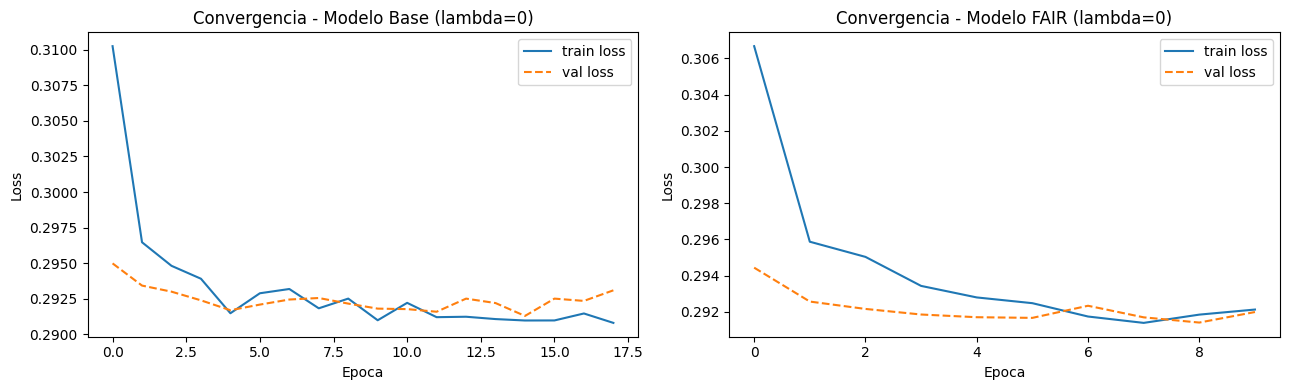

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, hist, title in zip(
    axes,
    [history_base, history_fair],
    ["Modelo Base (lambda=0)", f"Modelo FAIR (lambda={lambda_star:.0f})"],
):
    ax.plot(hist.history["loss"],     label="train loss", linewidth=1.5)
    ax.plot(hist.history["val_loss"], label="val loss",   linewidth=1.5, linestyle="--")
    ax.set_title(f"Convergencia - {title}")
    ax.set_xlabel("Epoca")
    ax.set_ylabel("Loss")
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS, "loss_curves.png"), dpi=150)
plt.show()

---

## 6. Evaluacion en test y tabla comparativa

Evaluamos ambos modelos sobre el **conjunto de test** (datos nunca vistos durante entrenamiento ni seleccion de arquitectura).

| Metrica | Que mide |
|---|---|
| **AUC** | Capacidad discriminativa general (objetivo principal) |
| **Accuracy** | Porcentaje de aciertos con umbral 0.5 |
| **rho Pearson** | Correlacion lineal entre y_hat y genero (idealmente 0) |
| **rho2 Pearson** | Intensidad de la dependencia (siempre >= 0) |

> `rho2 Pearson` bajo en el modelo FAIR confirma que la penalizacion funciono. La diferencia en AUC cuantifica el coste real en rendimiento predictivo.

In [22]:
def evaluar_modelo(model, Xc, Xd, y_ext):
    y_pred = model.predict([Xc, Xd], verbose=0).ravel()
    y_true = y_ext[:, 0]
    s      = y_ext[:, 1]
    auc    = roc_auc_score(y_true, y_pred)
    acc    = ((y_pred > 0.5).astype(int) == y_true.astype(int)).mean()
    rho    = float(np.corrcoef(y_pred, s)[0, 1])
    return {"AUC": round(auc, 4), "Accuracy": round(acc, 4),
            "rho_Pearson": round(rho, 6), "rho2_Pearson": round(rho**2, 6)}

resultados = {
    "base (lambda=0)": evaluar_modelo(model_base, X_custom_test, X_dense_test, y_test_ext),
    f"fair (lambda={lambda_star:.0f})": evaluar_modelo(model_fair, X_custom_test, X_dense_test, y_test_ext),
}

results_df = pd.DataFrame(resultados).T
results_df.index.name = "modelo"
results_df.to_csv(os.path.join(ARTIFACTS, "results_table.csv"))
print(results_df.to_string())
print(f"\nGuardado: {os.path.join(ARTIFACTS, 'results_table.csv')}")

                    AUC  Accuracy  rho_Pearson  rho2_Pearson
modelo                                                      
base (lambda=0)  0.7205    0.9193     0.036869      0.001359
fair (lambda=0)  0.7054    0.9193     0.002065      0.000004

Guardado: ../artifacts\results_table.csv


---

## 7. Persistencia de artefactos de preprocesado

Guardamos los scalers y los arrays procesados para que `03_uncertainty.ipynb` y `TALLER_B4_T1.ipynb` puedan reproducir el mismo preprocesado sin releer el CSV crudo.

- **`preprocessing.joblib`** -> scalers ajustados en train + nombres de features
- **`processed_data.npz`** -> los 12 arrays de los tres splits (cache opcional)

In [23]:
save_preprocessing(scalers, feature_names, ARTIFACTS)

splits = (
    X_custom_train, X_custom_val, X_custom_test,
    X_dense_train,  X_dense_val,  X_dense_test,
    y_train, y_val, y_test,
    s_train, s_val, s_test,
)
save_processed(splits, ARTIFACTS)

print("=== Artefactos generados ===")
for f in sorted(os.listdir(ARTIFACTS)):
    fpath = os.path.join(ARTIFACTS, f)
    if os.path.isfile(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  {f:<40} {size_kb:>8.1f} KB")

=== Artefactos generados ===
  base_model.keras                             45.1 KB
  best_model.keras                             37.9 KB
  fair_model.keras                             45.1 KB
  flowchart_modelo.png                         69.7 KB
  loss_curves.png                              90.5 KB
  pareto_data.csv                               0.3 KB
  pareto_frontier.png                          56.4 KB
  preprocessing.joblib                          1.3 KB
  processed_data.npz                        10467.0 KB
  results_table.csv                             0.1 KB
  uncertainty_model.keras                       0.0 KB
